In [1]:
import pandas as pd 

data = pd.read_csv("../bin/test.csv")
data

,Date,sun_RA,sun_Dec,mercury_RA,mercury_Dec,venus_RA,venus_Dec,mars_RA,mars_Dec,jupiter_RA,jupiter_Dec,saturn_RA,saturn_Dec,uranus_RA,uranus_Dec,neptune_RA,neptune_Dec
0,2010-03-28,150.670777,12.115832,66.728931,24.110410,49.143913,16.620580,157.302971,11.409461,343.930840,-8.085031,182.126970,1.586036,357.134636,-2.062906,328.658828,-13.178772
1,2010-03-29,150.743321,12.090270,73.476774,25.658977,50.741863,17.115107,157.714551,11.245865,344.015610,-8.051355,182.158083,1.573153,357.144439,-2.058630,328.664686,-13.176903
2,2010-03-30,150.815847,12.064688,80.384751,26.889180,52.348564,17.597120,158.125654,11.081707,344.100372,-8.017659,182.189194,1.560271,357.154242,-2.054354,328.670544,-13.175033
3,2010-03-31,150.888358,12.039086,87.395605,27.773202,53.964087,18.066161,158.536292,10.916995,344.185128,-7.983943,182.220302,1.547390,357.164046,-2.050078,328.676402,-13.173163
4,2010-04-01,150.960852,12.013465,94.441654,28.295090,55.588475,18.521780,158.946474,10.751735,344.269876,-7.950207,182.251408,1.534509,357.173849,-2.045802,328.682259,-13.171293
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5470,2025-03-19,222.851094,-15.034046,164.427211,13.691996,177.832898,4.582354,146.714351,15.343211,84.262024,22.979540,353.428079,-5.146306,54.016690,19.090338,359.821289,-1.499259
5471,2025-03-20,222.905861,-15.050565,168.580199,11.735077,179.303897,3.926671,147.142045,15.196081,84.355347,22.984818,353.458773,-5.133962,54.028290,19.093122,359.826895,-1.496967
5472,2025-03-21,222.960621,-15.067065,172.543069,9.784813,180.771906,3.268712,147.568990,15.048197,84.448665,22.990041,353.489467,-5.121615,54.039889,19.095905,359.832501,-1.494675
5473,2025-03-22,223.015376,-15.083547,176.336190,7.852897,182.237310,2.608917,147.995195,14.899567,84.541977,22.995209,353.520163,-5.109267,54.051490,19.098687,359.838106,-1.492382


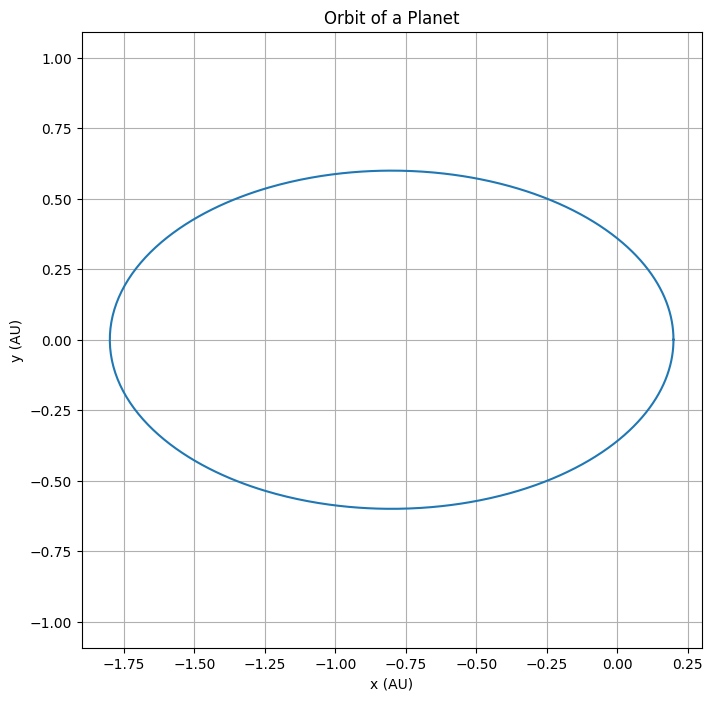

In [2]:
theta = np.linspace(0, 2 * np.pi, 1000)
a = 1
e = 0.8
r = a * (1 - e**2) / (1 + e * np.cos(theta))

x = r * np.cos(theta)
y = r * np.sin(theta)

import matplotlib.pyplot as plt
plt.figure(figsize=(8, 8))
plt.plot(x, y)
plt.title("Orbit of a Planet")
plt.xlabel("x (AU)")
plt.ylabel("y (AU)")
plt.axis('equal')
plt.grid()
plt.show()

In [3]:
from utils import get_date_indexs

In [10]:
def get_date_indexs(start_date_str, end_date_str, date_step, date_list):
    """
    Get the date indexs for the given start and end dates with a specified step (period).
    
    Arguments
    ---------
    start_date_str: str
    Start date in 'YYYY-MM-DD' format.
    
    end_date_str: str
    End date in 'YYYY-MM-DD' format.
    
    date_step: int
    Step size in days.
    
    date_list: pd.Series
    List of dates in 'YYYY-MM-DD' format to search for the indexs.

    Returns
    -------
    dates: list of str
    List of dates from start to end with the specified step.
    """
    # Convert start_date and end_date to datetime objects
    print(start_date_str)
    start_date = np.datetime64(start_date_str)
    end_date = np.datetime64(end_date_str)
    
    # Generate the date range with the specified step
    dates = np.arange(start_date, end_date + np.timedelta64(1, 'D'), np.timedelta64(date_step, 'D'))
    
    # Find indexs in the date_list
    indexs = [np.where(date_list == str(date))[0] for date in dates] 
    
    return np.array(indexs).flatten()

start_date = data.loc[0, "Date"]
end_date = data.loc[data.shape[0] -1, "Date"]
indexs = get_date_indexs(start_date, end_date, 365, data["Date"])
indexs

2010-03-28


array([   0,  365,  730, 1095, 1460, 1825, 2190, 2555, 2920, 3285, 3650,
       4015, 4380, 4745, 5110])

In [11]:
data["Date"][indexs]

0       2010-03-28
365     2011-03-28
730     2012-03-27
1095    2013-03-27
1460    2014-03-27
1825    2015-03-27
2190    2016-03-26
2555    2017-03-26
2920    2018-03-26
3285    2019-03-26
3650    2020-03-25
4015    2021-03-25
4380    2022-03-25
4745    2023-03-25
5110    2024-03-24
Name: Date, dtype: object

In [13]:
15*365.25/687

7.974890829694323